<a href="https://colab.research.google.com/github/ibtihalalf/Sdaia-Bootcamp/blob/main/C4/M3/Ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1 : RAG Agent

In [7]:
!pip install -q langchain langchain-community langchain-openai pypdf

In [8]:
import os

from google.colab import files

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings

from langchain_core.vectorstores import InMemoryVectorStore

In [9]:
try:
    # In Colab? read from userdata (secrets)
    from google.colab import userdata
    ON_COLAB = True
    os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
except ImportError:
    # Load `.env` file (locally)
    from dotenv import load_dotenv
    load_dotenv(override=True)

Upload PDF Files

In [10]:
uploaded = files.upload()

pdf_paths = list(uploaded.keys())

print(pdf_paths)

Saving iso27001.pdf to iso27001 (3).pdf
['iso27001 (3).pdf']


Load Documents

In [11]:
docs = []

for pdf in pdf_paths:
    loader = PyPDFLoader(pdf)
    docs.extend(loader.load())

print(f"Loaded pages: {len(docs)}")

Loaded pages: 26


Split Documents into Chunks

In [12]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

splits = text_splitter.split_documents(docs)

print(f"Total chunks: {len(splits)}")

Total chunks: 76


Create Embeddings + InMemory Vector Store

In [13]:
from google.colab import userdata

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY"),
)

vector_store = InMemoryVectorStore.from_documents(
    documents=splits,
    embedding=embeddings
)

Create Retriever

In [14]:
retriever = vector_store.as_retriever(
    search_kwargs={"k": 4}
)

Test Retrieval

In [15]:
query = "What is the main topic of the documents?"

results = retriever.invoke(query)

for i, doc in enumerate(results, start=1):
    print(f"\n--- Result {i} ---")
    print(doc.page_content[:500])


--- Result 1 ---
7.5  Documented information  ..............................................................................................................................................................6
7.5.1  General ........................................................................................................................................................................................ 6
7.5.2  Creating and updating  ...............................................................................

--- Result 2 ---
this document.
2  Normative references
The following documents are referred to in the text in such a way that some or all of their content 
constitutes requirements of this document. For dated references, only the edition cited applies. For 
undated references, the latest edition of the referenced document (including any amendments) applies.
ISO/IEC 27000, Information technology — Security techniques — Information security management 
systems — Overview and v

Create RAG Prompt

In [16]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
Answer the question using ONLY the context below.

Context:
{context}

Question:
{question}
""")

Create LLM

In [17]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY"),
    temperature=0
)

Ask Questions

In [18]:
question = "Summarize the documents."

retrieved_docs = retriever.invoke(question)

context = "\n\n".join(
    [doc.page_content for doc in retrieved_docs]
)

formatted_prompt = prompt.invoke({
    "context": context,
    "question": question
})

response = llm.invoke(formatted_prompt)

print(response.content)

The document outlines requirements and guidelines related to information security management systems, referencing ISO/IEC 27000 for terms and definitions. It includes sections on documented information, competence, awareness, and communication, emphasizing the need for documented operating procedures and regular reviews of compliance with the organization's information security policies. The structure includes normative references and a context of the organization, highlighting the importance of understanding the organization's context in relation to information security.


Task 2: Replace InMemoryVectorStore with ChromaDB

In [19]:
!pip install -q chromadb langchain-chroma

In [20]:
!pip uninstall -y opentelemetry-api opentelemetry-sdk opentelemetry-semantic-conventions

!pip install -q \
opentelemetry-api==1.27.0 \
opentelemetry-sdk==1.27.0 \
opentelemetry-semantic-conventions==0.48b0

!pip install -q chromadb langchain-chroma

Found existing installation: opentelemetry-api 1.41.1
Uninstalling opentelemetry-api-1.41.1:
  Successfully uninstalled opentelemetry-api-1.41.1
Found existing installation: opentelemetry-sdk 1.41.1
Uninstalling opentelemetry-sdk-1.41.1:
  Successfully uninstalled opentelemetry-sdk-1.41.1
Found existing installation: opentelemetry-semantic-conventions 0.62b1
Uninstalling opentelemetry-semantic-conventions-0.62b1:
  Successfully uninstalled opentelemetry-semantic-conventions-0.62b1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-exporter-otlp-proto-grpc 1.41.1 requires opentelemetry-sdk~=1.41.1, but you have opentelemetry-sdk 1.27.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-exporter-otlp-proto-common==1.38.0, but you have opentelemetry-exporter-otlp-proto-common 1.41.1 which is incompatible.
opentel

In [21]:
from pathlib import Path
from langchain_chroma import Chroma

Create Persistent ChromaDB

In [22]:
persist_directory = "./chroma_rag_db"

collection_name = "rag_documents"

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY"),
)

Check if Database Already Exists

In [23]:
db_exists = Path(persist_directory).exists()

if db_exists:

    print("Loading existing database...")

    vector_store = Chroma(
        collection_name=collection_name,
        embedding_function=embeddings,
        persist_directory=persist_directory
    )

else:

    print("Creating new database and embeddings...")

    vector_store = Chroma.from_documents(
        documents=splits,
        embedding=embeddings,
        collection_name=collection_name,
        persist_directory=persist_directory
    )

Loading existing database...


Create Retriever

In [24]:
retriever = vector_store.as_retriever(
    search_kwargs={"k": 4}
)

Query Similar Documents

In [25]:
query = "What is the main topic?"

results = retriever.invoke(query)

for i, doc in enumerate(results, start=1):
    print(f"\n--- Result {i} ---")
    print(doc.page_content[:500])


--- Result 1 ---
— IEC Electropedia: available at h t t p s :// www .electropedia  .org/ 
4  Context of the organization
4.1  Understanding the organization and its context
The organization shall determine external and internal issues that are relevant to its purpose and that 
affect its ability to achieve the intended outcome(s) of its information security management system.
NOTE Determining these issues refers to establishing the external and internal context of the organization 
considered in Clause 5.4.1 of 

--- Result 2 ---
3	 	Terms	and	definitions .................................................................................................................................................................................... 1
4  Context of the organization  ...................................................................................................................................................................... 1
4.1  Understanding the organization and its context  

Verify Persistence

In [26]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
import os
from google.colab import userdata

persist_directory = "./chroma_rag_db"

collection_name = "rag_documents"

os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY"),
)

vector_store = Chroma(
    collection_name=collection_name,
    embedding_function=embeddings,
    persist_directory=persist_directory
)

retriever = vector_store.as_retriever()

results = retriever.invoke(
    "What is the main topic?"
)

for doc in results:
    print(doc.page_content[:500])

— IEC Electropedia: available at h t t p s :// www .electropedia  .org/ 
4  Context of the organization
4.1  Understanding the organization and its context
The organization shall determine external and internal issues that are relevant to its purpose and that 
affect its ability to achieve the intended outcome(s) of its information security management system.
NOTE Determining these issues refers to establishing the external and internal context of the organization 
considered in Clause 5.4.1 of 
3	 	Terms	and	definitions .................................................................................................................................................................................... 1
4  Context of the organization  ...................................................................................................................................................................... 1
4.1  Understanding the organization and its context  ....................................

Task 3: Embedding Visualization

Goal : Visualize the document chunks to see if similar texts form clusters.

In [27]:
!pip install -q pandas matplotlib scikit-learn

In [28]:
texts = [doc.page_content for doc in splits]

print(f"Number of text chunks: {len(texts)}")
print(texts[0][:500])

Number of text chunks: 76
Information security, cybersecurity 
and privacy protection — Information 
security management systems — 
Requirements
Sécurité de l'information, cybersécurité et protection de la vie 
privée — Systèmes de management de la sécurité de l'information — 
Exigences
INTERNATIONAL 
STANDARD
ISO/IEC 
27001
Third edition  
2022-10
Reference number 
ISO/IEC 27001:2022(E)
© ISO/IEC 2022
--``,,,,,``````,,,,,`,`,`,`,,`,-`-`,,`,,`,`,,`---


Create Embeddings

In [29]:
embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY"),
)

embedding_vectors = embeddings_model.embed_documents(texts)

print(f"Number of embeddings: {len(embedding_vectors)}")
print(f"Embedding dimension: {len(embedding_vectors[0])}")

Number of embeddings: 76
Embedding dimension: 1536


Reduce Embeddings to 2D using PCA

In [30]:
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(embedding_vectors)

df = pd.DataFrame(
    reduced_embeddings,
    columns=["x", "y"]
)

df["text"] = texts

df.head()

,x,y,text
0,0.344385,0.063133,"Information security, cybersecurity \nand priv..."
1,0.421765,-0.158786,ii\nISO/IEC 27001:2022(E)\nCOPYRIGHT PROTECTED...
2,0.461520,0.029132,ISO/IEC 27001:2022(E)\nForeword .................
3,-0.173856,0.161149,3\t \tTerms\tand\tdefinitions ...................
4,-0.262530,0.138454,4.4 Information security management system ....


Visualize the Embeddings

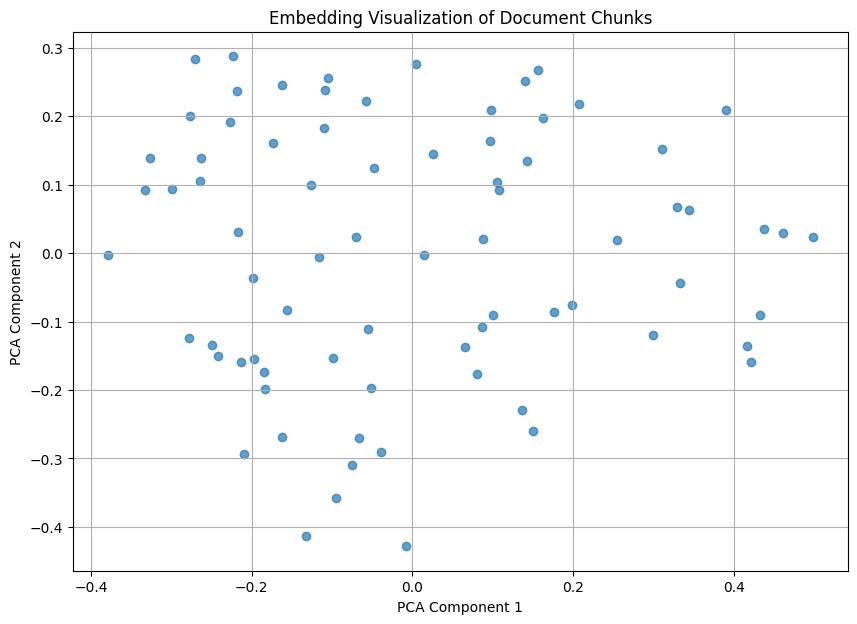

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    df["x"],
    df["y"],
    alpha=0.7
)

plt.title("Embedding Visualization of Document Chunks")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)

plt.show()

Create Clusters with KMeans

In [33]:
from sklearn.cluster import KMeans

num_clusters = 4

kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init="auto"
)

df["cluster"] = kmeans.fit_predict(embedding_vectors)

df.head()

,x,y,text,label,cluster
0,0.344385,0.063133,"Information security, cybersecurity \nand priv...","Information security, cybersecurity \nand...",3
1,0.421765,-0.158786,ii\nISO/IEC 27001:2022(E)\nCOPYRIGHT PROTECTED...,ii\nISO/IEC 27001:2022(E)\nCOPYRIGHT PROTE...,1
2,0.461520,0.029132,ISO/IEC 27001:2022(E)\nForeword .................,ISO/IEC 27001:2022(E)\nForeword ............,3
3,-0.173856,0.161149,3\t \tTerms\tand\tdefinitions ...................,3\t \tTerms\tand\tdefinitions .................,0
4,-0.262530,0.138454,4.4 Information security management system ....,4.4 Information security management sys...,0


Visualize Clusters

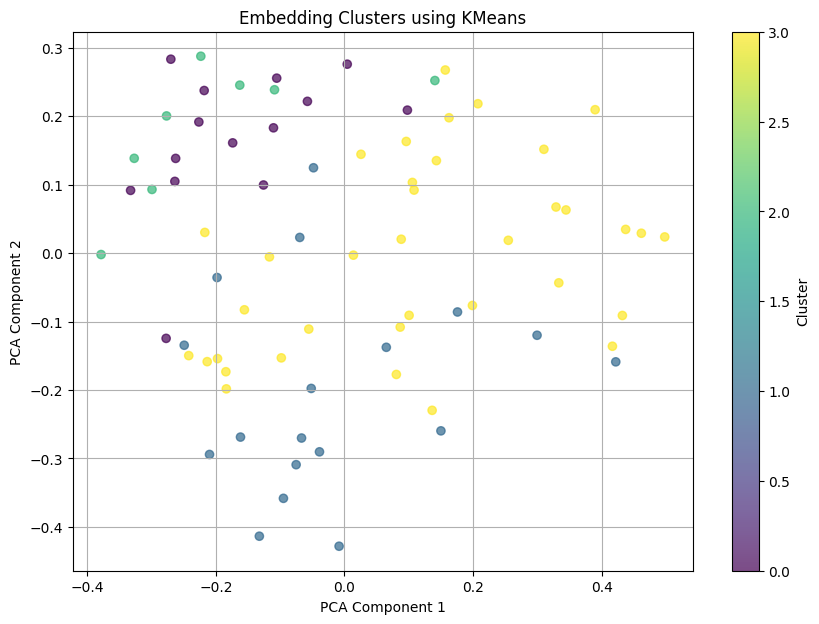

In [34]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df["x"],
    df["y"],
    c=df["cluster"],
    alpha=0.7
)

plt.title("Embedding Clusters using KMeans")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.show()

Inspect Texts Inside Each Cluster

In [35]:
for cluster_id in sorted(df["cluster"].unique()):
    print(f"\n==============================")
    print(f"Cluster {cluster_id}")
    print("==============================")

    cluster_texts = df[df["cluster"] == cluster_id]["text"].head(3)

    for text in cluster_texts:
        print(text[:500])
        print("---")


Cluster 0
3	 	Terms	and	definitions .................................................................................................................................................................................... 1
4  Context of the organization  ...................................................................................................................................................................... 1
4.1  Understanding the organization and its context  .....................................
---
4.4  Information security management system  ................................................................................................................... 2
5  Leadership  ..................................................................................................................................................................................................................2
5.1  Leadership and commitment ...............................................................